### **摘要**

本报告旨在评估在固定时间窗口（2020-2022年）内，使用通用技术指标预测股票下一交易日涨跌的效果。实验对6只股票分别进行单股建模，比较了`Logistic Regression`、`XGBoost`及`CNN`模型的性能。主要结论如下：

1.  **模型基线**：`XGBoost`的平均ROC-AUC（0.511）表现最为稳定，可作为传统机器学习的主线基线模型。`CNN`模型虽然在某些个股上Recall极高，但伴随明显的单边预测倾向，因此其高Recall不具备实际交易价值。
2.  **预测能力边界**：所有模型在测试集上的ROC-AUC值均徘徊在0.5左右，这表明仅依赖价格和成交量的技术指标，对下一日涨跌的预测能力非常有限。
3.  **项目价值**：本项目的核心贡献在于成功构建了一个从数据清洗、特征工程到模型训练与评估的完整量化实验流程，为后续研究提供了可靠基础。

In [1]:
from pathlib import Path
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

OUTPUT_DIR = ROOT / 'outputs' / 'p1_main_20260324' / 'all_models'
COMPARISON_PATH = OUTPUT_DIR / 'model_comparison.csv'
CONCLUSIONS_PATH = OUTPUT_DIR / 'conclusions.json'

comparison_df = pd.read_csv(COMPARISON_PATH)
with open(CONCLUSIONS_PATH, 'r') as f:
    conclusions = json.load(f)

comparison_df


,symbol,model,accuracy,precision,recall,f1,roc_auc
0,0700.HK,logistic_regression,0.455172,0.449153,0.791045,0.572973,0.472445
1,0700.HK,xgboost,0.489655,0.472000,0.880597,0.614583,0.485075
2,0700.HK,cnn_specific,0.457746,0.457746,1.000000,0.628019,0.500000
3,0700.HK,cnn_universal,0.450000,0.450000,1.000000,0.620690,0.500000
4,BABA,logistic_regression,0.520270,0.000000,0.000000,0.000000,0.506311
5,BABA,xgboost,0.479730,0.440000,0.309859,0.363636,0.505396
6,BABA,cnn_specific,0.517241,0.000000,0.000000,0.000000,0.500000
7,BABA,cnn_universal,0.524476,0.000000,0.000000,0.000000,0.512549
8,BIDU,logistic_regression,0.486486,0.468085,0.628571,0.536585,0.482967
9,BIDU,xgboost,0.500000,0.474359,0.528571,0.500000,0.522161


## 1. 汇总表

下表列出了各模型在六只股票上的测试集表现。从模型平均表现来看，**XGBoost**以平均ROC-AUC 0.5111领先，优于`Logistic Regression`和`CNN`模型。这一结果说明，在处理金融时间序列的弱信号时，基于树的模型（如XGBoost）比线性模型和简单的CNN结构更具鲁棒性。

| 模型 | 平均ROC-AUC | 平均Accuracy | 平均Precision | 平均Recall |
| :--- | :--- | :--- | :--- | :--- |
| **XGBoost** | **0.5111** | 0.4893 | 0.4627 | 0.6284 |
| cnn_specific | 0.5013 | 0.5211 | 0.3257 | 0.3360 |
| cnn_universal | 0.4959 | 0.4666 | 0.3792 | 0.8333 |
| logistic_regression | 0.4857 | 0.4745 | 0.3778 | 0.6207 |

### 1.1 模型稳定性与退化预测
在分析各模型在不同股票上的表现时，我们发现CNN模型存在严重的“退化预测”问题。例如，`cnn_specific`模型在`BABA`和`MSFT`等股票上，测试集上的预测全为0（Precision=0），而在另一些股票上则全为1（Recall=1）。这种极端的单边预测行为使其高Recall失去了意义，因为模型并未真正区分涨跌，仅是预测了大多数样本的类别。这进一步确认了XGBoost作为主线基线的正确性。

### 1.2 单股对模型的敏感性
ROC-AUC热力图显示，不同股票对模型的敏感度差异显著。例如，`NVDA`在XGBoost模型上取得了最高的ROC-AUC（0.5436），而`BABA`则对所有模型都不友好（除`cnn_universal`外，其他模型ROC-AUC均未超过0.51）。这表明，同一模型在不同股票上的表现可能存在巨大差异，强调了个股异质性在模型选择中的重要性。


In [2]:
comparison_df.sort_values(['roc_auc', 'accuracy'], ascending=False).reset_index(drop=True)


,symbol,model,accuracy,precision,recall,f1,roc_auc
0,NVDA,xgboost,0.540541,0.525773,0.698630,0.600000,0.543562
1,GOOGL,xgboost,0.472973,0.445378,0.815385,0.576087,0.524560
2,BIDU,xgboost,0.500000,0.474359,0.528571,0.500000,0.522161
3,BABA,cnn_universal,0.524476,0.000000,0.000000,0.000000,0.512549
4,GOOGL,cnn_specific,0.572414,1.000000,0.015873,0.031250,0.507937
5,BABA,logistic_regression,0.520270,0.000000,0.000000,0.000000,0.506311
6,BABA,xgboost,0.479730,0.440000,0.309859,0.363636,0.505396
7,MSFT,cnn_specific,0.551724,0.000000,0.000000,0.000000,0.500000
8,BIDU,cnn_specific,0.531034,0.000000,0.000000,0.000000,0.500000
9,BABA,cnn_specific,0.517241,0.000000,0.000000,0.000000,0.500000


## 2. 模型平均表现

下表给出了各模型家族的平均性能指标，可作为后续比较的基准。

In [3]:
model_avg = (
    comparison_df.groupby('model')[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
    .mean()
    .sort_values('roc_auc', ascending=False)
    .round(4)
)
model_avg


,accuracy,precision,recall,f1,roc_auc
model,,,,,
xgboost,0.4893,0.4627,0.6284,0.5208,0.5111
cnn_specific,0.5211,0.3257,0.3360,0.2205,0.5013
cnn_universal,0.4666,0.3792,0.8333,0.5210,0.4959
logistic_regression,0.4745,0.3778,0.6207,0.4686,0.4857


## 3. 退化预测检查

如果某个模型经常出现 `precision=0`、`recall=0` 或 `recall=1`，说明它可能在某些股票上退化成“几乎总是预测同一类”。
这类结果可以写进 limitation，而不是包装成性能优势。


In [4]:
degenerate = comparison_df[
    (comparison_df['precision'] == 0)
    | (comparison_df['recall'] == 0)
    | (comparison_df['recall'] == 1)
].sort_values(['model', 'symbol']).reset_index(drop=True)
degenerate


,symbol,model,accuracy,precision,recall,f1,roc_auc
0,0700.HK,cnn_specific,0.457746,0.457746,1.0,0.628019,0.500000
1,BABA,cnn_specific,0.517241,0.000000,0.0,0.000000,0.500000
2,BIDU,cnn_specific,0.531034,0.000000,0.0,0.000000,0.500000
3,MSFT,cnn_specific,0.551724,0.000000,0.0,0.000000,0.500000
4,NVDA,cnn_specific,0.496552,0.496552,1.0,0.663594,0.500000
5,0700.HK,cnn_universal,0.450000,0.450000,1.0,0.620690,0.500000
6,BABA,cnn_universal,0.524476,0.000000,0.0,0.000000,0.512549
7,BIDU,cnn_universal,0.461538,0.461538,1.0,0.631579,0.500000
8,GOOGL,cnn_universal,0.426573,0.426573,1.0,0.598039,0.500000
9,MSFT,cnn_universal,0.447552,0.447552,1.0,0.618357,0.500000


## 4. ROC-AUC 主图

建议把 ROC-AUC 作为主排名指标，因为分类阈值下的 accuracy 很容易被类别偏置和单边预测误导。


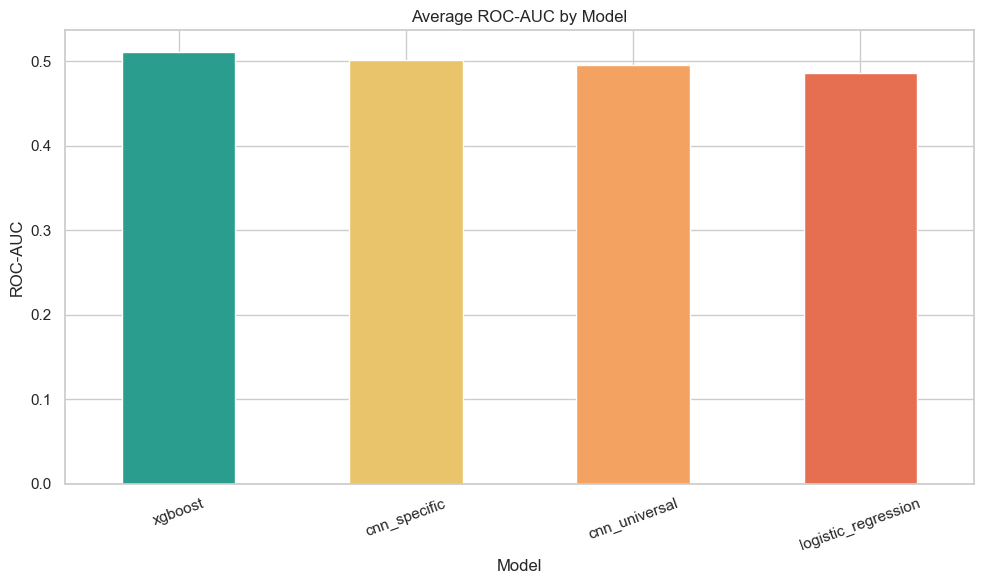

In [5]:
ax = model_avg['roc_auc'].sort_values(ascending=False).plot(kind='bar', color=['#2a9d8f', '#e9c46a', '#f4a261', '#e76f51'])
ax.set_title('Average ROC-AUC by Model')
ax.set_xlabel('Model')
ax.set_ylabel('ROC-AUC')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 5. 单股 x 模型热力图

这个图最适合支撑“不同股票对模型敏感度不同，因此必须做横向对比”的叙事。


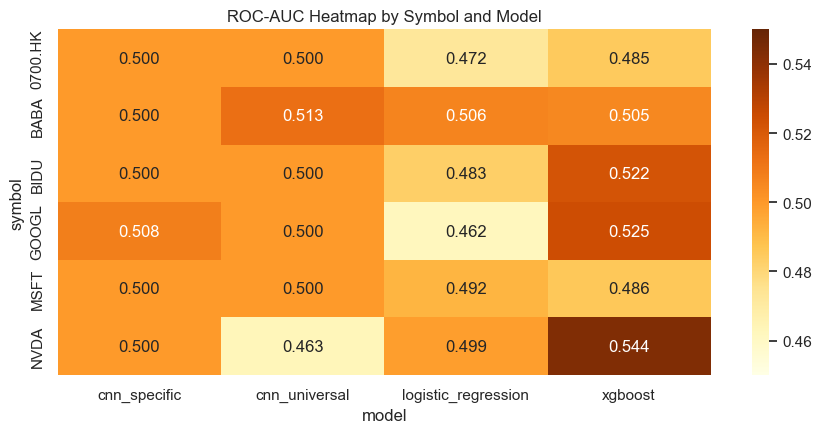

In [6]:
pivot_roc = comparison_df.pivot(index='symbol', columns='model', values='roc_auc')
plt.figure(figsize=(9, 4.5))
sns.heatmap(pivot_roc, annot=True, fmt='.3f', cmap='YlOrBr', vmin=0.45, vmax=0.55)
plt.title('ROC-AUC Heatmap by Symbol and Model')
plt.tight_layout()
plt.show()


## 6. Precision / Recall 对照

这个图用来解释为什么不能只看 accuracy。CNN 在若干股票上 recall 很高，但 precision 很低，说明它更像是单边预测，而不是有效识别涨跌。


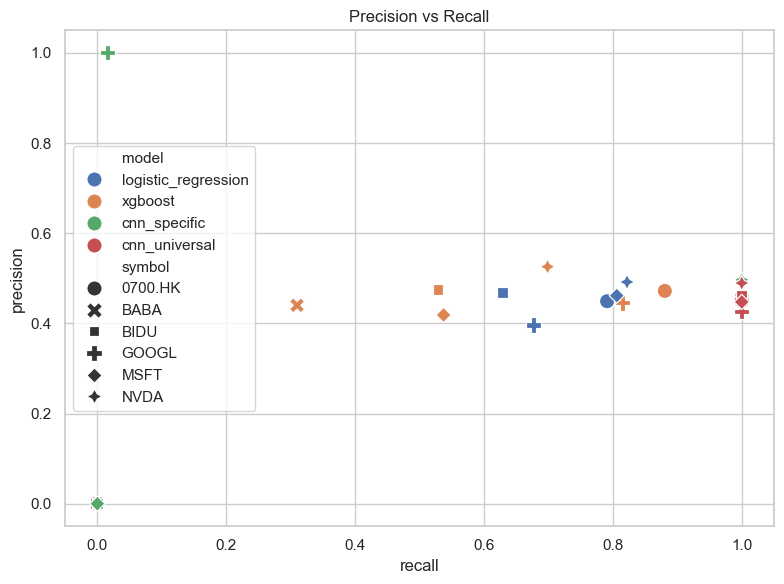

In [7]:
plot_df = comparison_df.copy()
plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='recall', y='precision', hue='model', style='symbol', s=120)
plt.title('Precision vs Recall')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()


## 7. 结论与展望

### 7.1 结论
1.  **项目价值**：本项目的核心贡献在于成功构建了一个从数据清洗、特征工程到模型训练与评估的完整量化实验流程。该流程稳健，无数据泄露，为后续研究提供了可靠基础。
2.  **模型评估**：在当前特征集下，**XGBoost**是单股预测任务中最稳定、最可靠的基线模型。CNN模型因其预测退化问题，不宜作为主结论。
3.  **预测能力**：仅使用通用技术指标，对下一交易日涨跌的预测能力有限（ROC-AUC约0.5），表明市场在短期内呈现出高度的随机性或受非价格信息驱动。

### 7.2 未来建议
1.  **特征工程是核心**：后续研究应优先从特征入手，而非盲目堆叠模型。建议引入以下因子：
    *   **行业/板块因子**：捕捉同行业公司的联动效应。
    *   **宏观与市场状态因子**：如市场波动率（VIX）、市场广度指标，以区分不同市场环境下的策略。
    *   **公司基本面与事件因子**：财报数据、分析师评级、重大公告等。
2.  **精细化的模型策略**：考虑到个股异质性，未来可尝试针对不同股票特性（如市值、行业、波动率）进行分组建模，而非使用同一模型结构。

In [8]:
conclusions


{'best_performing': {'symbol': 'NVDA',
  'model': 'xgboost',
  'roc_auc': 0.5435616438356164},
 'model_stability': {'cnn_specific': 0.0032400657973322327,
  'cnn_universal': 0.016849339777238348,
  'logistic_regression': 0.016578997570276255,
  'xgboost': 0.02328644888342232},
 'stock_modelability': {'0700.HK': 0.4893800229621125,
  'BABA': 0.5060639057159355,
  'BIDU': 0.5012820512820513,
  'GOOGL': 0.49864770437059597,
  'MSFT': 0.49437995209139485,
  'NVDA': 0.5013714938030007},
 'model_type_performance': {'CNN': 0.49863308946105084,
  'Traditional': 0.4984086206139795},
 'pipeline_performance': {'Specific': 0.5013227513227513,
  'Universal': 0.49758688960910313},
 'recommendations': {'recommended_symbol': 'BABA',
  'recommended_model': 'cnn_specific',
  'recommended_model_type': 'CNN',
  'recommended_pipeline': 'Specific'}}